# NOWA WERSJA

In [30]:
import os
os.chdir('..') 
print("Now working from:", os.getcwd())

Now working from: /Users/zofiabrodewicz/Documents/GitHub/Bachelor


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr


#sns.set(style="whitegrid")


In [32]:
df = pd.read_csv("collaboration_with_distances.csv")
df["log_streams"] = np.log1p(df["avg_streams"]) #depends what we need for the visualizations

## 1. Baseline Understanding

### 1.1 Distrubution of Distances Across Years

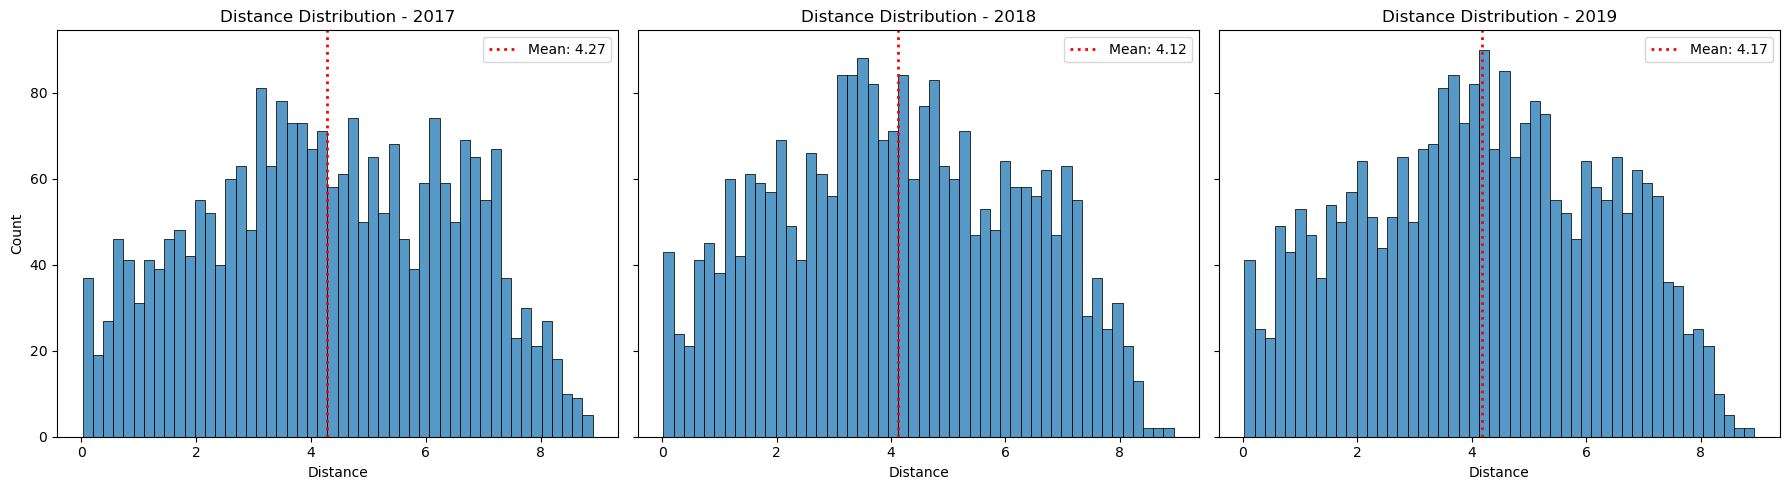

In [44]:
years = sorted(df["year"].unique())

fig, axes = plt.subplots(1, len(years), figsize=(18, 5), sharey=True)

for i, year in enumerate(years):
    subset = df[df["year"] == year]
    
    sns.histplot(subset["distance"], bins=50, kde=False, ax=axes[i]) #change kde to True to show an underlying distributional shape 
    
    # mean line 
    mean_val = subset["distance"].mean()
    axes[i].axvline(mean_val, color='red', linestyle=':', linewidth=2, label=f"Mean: {mean_val:.2f}")
    
    axes[i].set_title(f"Distance Distribution - {year}")
    axes[i].set_xlabel("Distance")
    
    axes[i].legend()

axes[0].set_ylabel("Count")

plt.tight_layout()
plt.show()

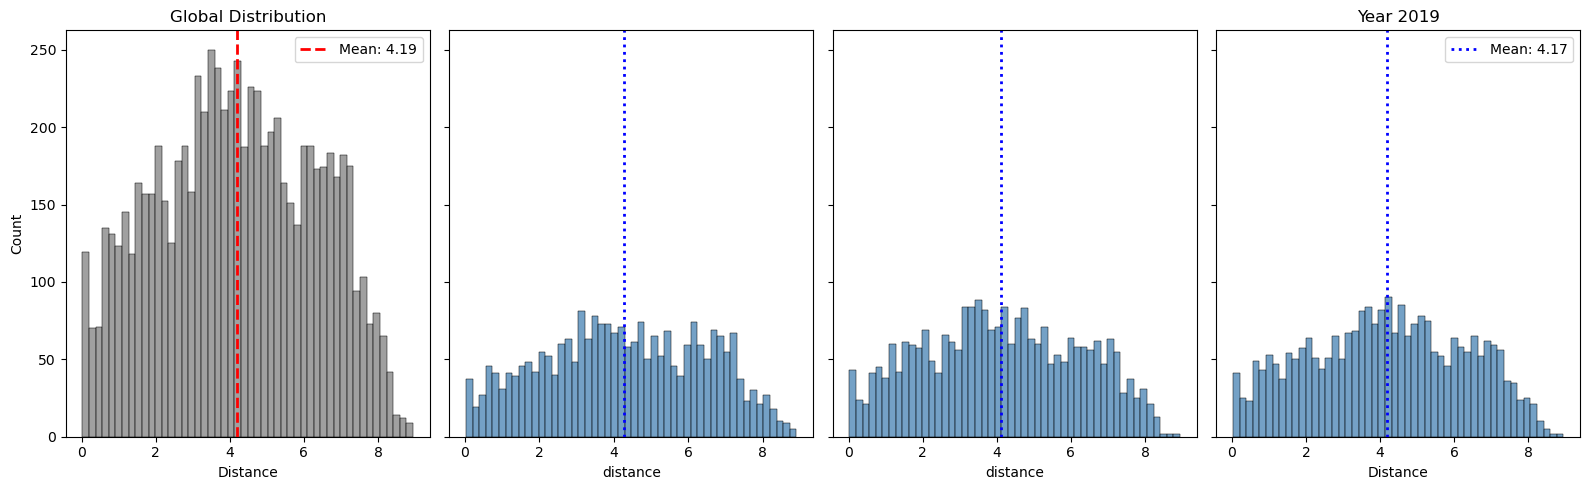

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

years = sorted(df["year"].unique())

# create 1 extra slot for global
n_plots = len(years) + 1

fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 5), sharey=True)


# -------------------------
# 2. YEARLY DISTRIBUTIONS
# -------------------------
for i, year in enumerate(years, start=1):
    subset = df[df["year"] == year]

    sns.histplot(subset["distance"], bins=50, kde=False, ax=axes[i], color="steelblue")

    axes[i].axvline(
        subset["distance"].mean(),
        color="blue",
        linestyle=":",
        linewidth=2,
        label=f"Mean: {subset['distance'].mean():.2f}"
    )

    # -------------------------
# 1. GLOBAL DISTRIBUTION
# -------------------------
sns.histplot(df["distance"], bins=50, kde=False, ax=axes[0], color="gray")

axes[0].axvline(
    df["distance"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {df['distance'].mean():.2f}"
)

axes[0].set_title("Global Distribution")
axes[0].set_xlabel("Distance")
axes[0].legend()


axes[i].set_title(f"Year {year}")
axes[i].set_xlabel("Distance")
axes[i].legend()

axes[0].set_ylabel("Count")

plt.tight_layout()
plt.show()

###  1.2 Correlation Between Distances and Popularity 

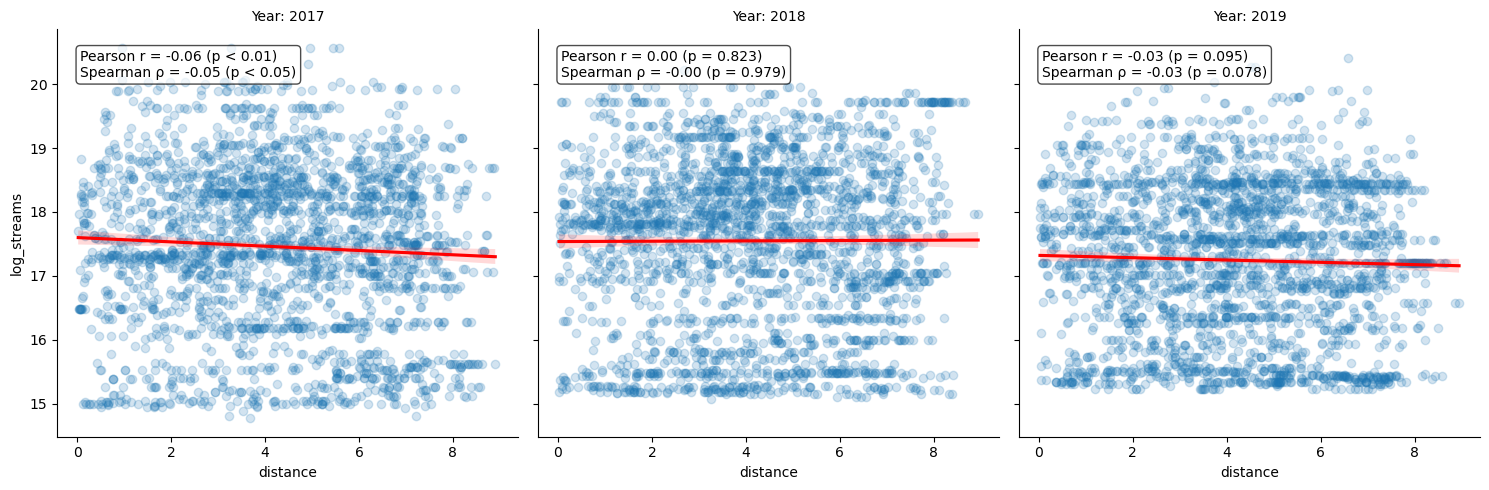

In [45]:
# --- helper to format p-values nicely ---
def format_p(p):
    if p < 0.001:
        return "p < 0.001"
    elif p < 0.01:
        return "p < 0.01"
    elif p < 0.05:
        return "p < 0.05"
    else:
        return f"p = {p:.3f}"

# --- create lmplot ---
g = sns.lmplot(
    x="distance", 
    y="log_streams", #change to avg_streams if we dont want log lormalized distances
    col="year", 
    data=df,
    height=5, 
    aspect=1,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)

g.set_titles("Year: {col_name}")

# --- compute stats per year ---
stats = {}
years = sorted(df["year"].unique())

for year in years:
    subset = df[df["year"] == year]
    
    pearson_corr, pearson_p = pearsonr(subset["distance"], subset["log_streams"])
    spearman_corr, spearman_p = spearmanr(subset["distance"], subset["log_streams"])
    
    stats[year] = (pearson_corr, pearson_p, spearman_corr, spearman_p)

# --- annotate each subplot ---
for ax, year in zip(g.axes.flat, years):
    r, rp, rho, sp = stats[year]
    
    ax.text(
        0.05, 0.95,
        f"Pearson r = {r:.2f} ({format_p(rp)})\n"
        f"Spearman ρ = {rho:.2f} ({format_p(sp)})",
        transform=ax.transAxes,
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

plt.show()

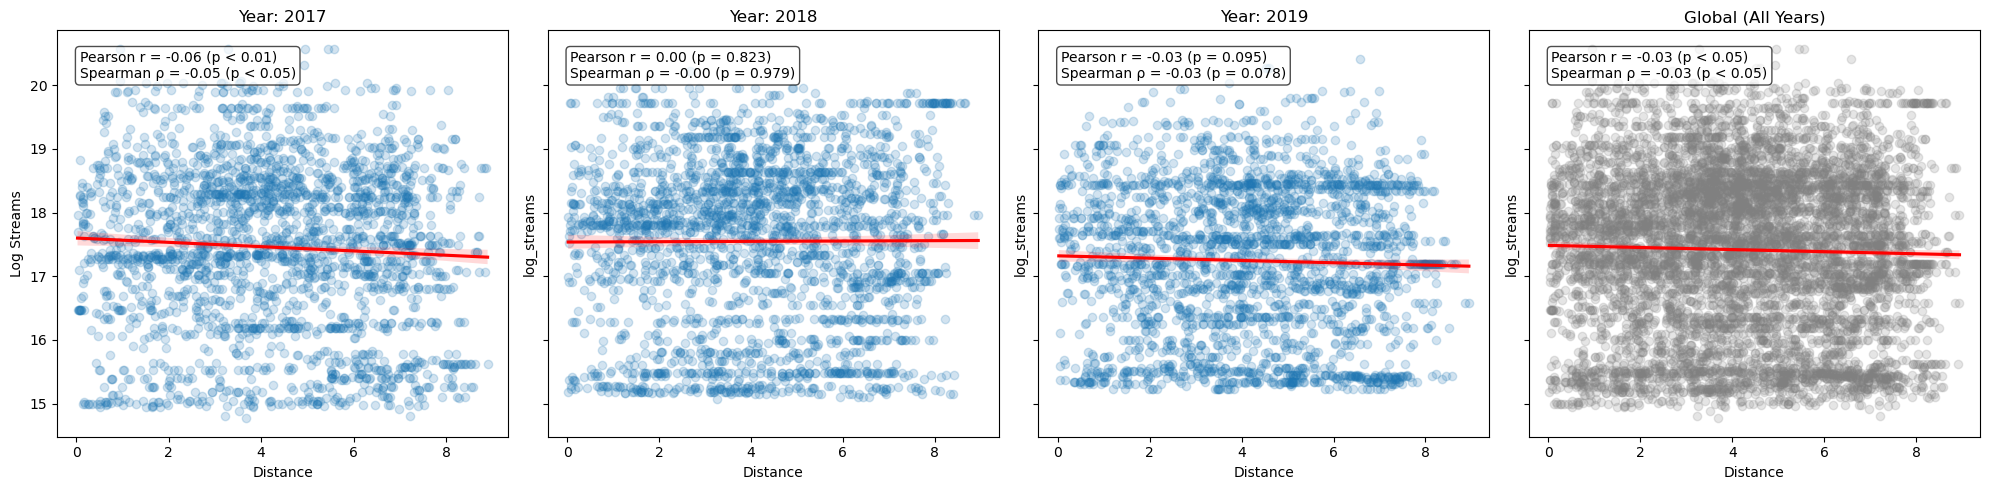

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# --- helper to format p-values nicely ---
def format_p(p):
    if p < 0.001:
        return "p < 0.001"
    elif p < 0.01:
        return "p < 0.01"
    elif p < 0.05:
        return "p < 0.05"
    else:
        return f"p = {p:.3f}"

# --- setup ---
years = sorted(df["year"].unique())
n_years = len(years)

fig, axes = plt.subplots(1, n_years + 1, figsize=(5 * (n_years + 1), 5), sharey=True)

stats = {}

# --- global plot ---
global_r, global_rp = pearsonr(df["distance"], df["log_streams"])
global_rho, global_sp = spearmanr(df["distance"], df["log_streams"])

sns.regplot(
    data=df,
    x="distance",
    y="log_streams",
    scatter_kws={"alpha": 0.2, "color": "grey"},
    line_kws={"color": "red"},
    ax=axes[-1]
)

axes[-1].set_title("Global (All Years)")

axes[-1].text(
    0.05, 0.95,
    f"Pearson r = {global_r:.2f} ({format_p(global_rp)})\n"
    f"Spearman ρ = {global_rho:.2f} ({format_p(global_sp)})",
    transform=axes[-1].transAxes,
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

# --- per-year plots ---
for i, year in enumerate(years):
    subset = df[df["year"] == year]

    sns.regplot(
        data=subset,
        x="distance",
        y="log_streams",
        scatter_kws={"alpha": 0.2},
        line_kws={"color": "red"},
        ax=axes[i]
    )

    # correlations
    r, rp = pearsonr(subset["distance"], subset["log_streams"])
    rho, sp = spearmanr(subset["distance"], subset["log_streams"])

    stats[year] = (r, rp, rho, sp)

    axes[i].set_title(f"Year: {year}")

    axes[i].text(
        0.05, 0.95,
        f"Pearson r = {r:.2f} ({format_p(rp)})\n"
        f"Spearman ρ = {rho:.2f} ({format_p(sp)})",
        transform=axes[i].transAxes,
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

# --- labels ---
for ax in axes:
    ax.set_xlabel("Distance")

axes[0].set_ylabel("Log Streams")

plt.tight_layout()
plt.show()

### 1.3 Popularity Across Distance Levels

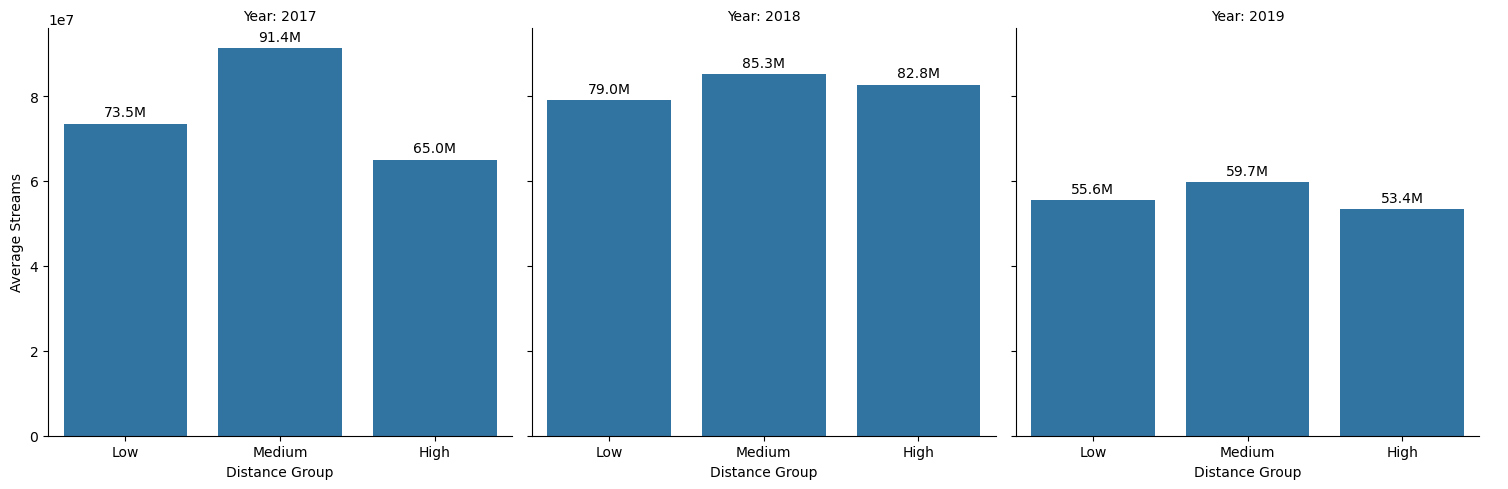

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- FIXED BINNING ---
bins = [
    df["distance"].min(),
    df["distance"].quantile(0.33),
    df["distance"].quantile(0.66),
    df["distance"].max()
]

labels = ["Low", "Medium", "High"]

df["distance_bin"] = pd.cut(
    df["distance"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# --- formatter ---
def format_millions(x):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.1f}K"
    else:
        return f"{x:.1f}"

# --- plot ---
g = sns.catplot(
    data=df,
    x="distance_bin",
    y="avg_streams",  #change to log_strema if we want to use log normalized distances 
    col="year",
    kind="bar",
    errorbar=None,
    height=5,
    aspect=1
)

g.set_titles("Year: {col_name}")
g.set_axis_labels("Distance Group", "Average Streams")

# --- labels ---
for ax in g.axes.flat:
    for container in ax.containers:
        labels = [format_millions(v) for v in container.datavalues]
        ax.bar_label(container, labels=labels, padding=3)

plt.show()

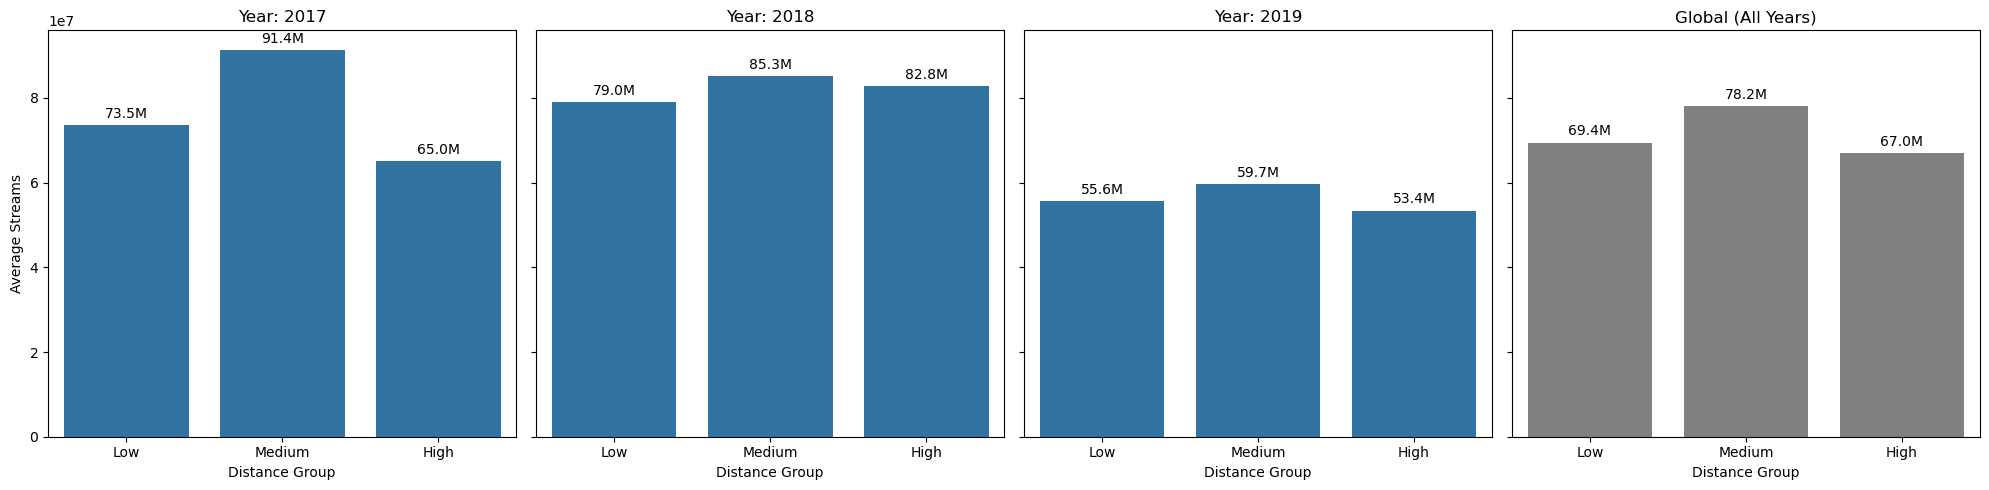

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- FIXED BINNING ---
bins = [
    df["distance"].min(),
    df["distance"].quantile(0.33),
    df["distance"].quantile(0.66),
    df["distance"].max()
]

labels = ["Low", "Medium", "High"]

df["distance_bin"] = pd.cut(
    df["distance"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# --- formatter ---
def format_millions(x):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.1f}K"
    else:
        return f"{x:.1f}"

# --- setup ---
years = sorted(df["year"].unique())
n_years = len(years)

fig, axes = plt.subplots(1, n_years + 1, figsize=(5 * (n_years + 1), 5), sharey=True)

# --- per-year bar plots ---
for i, year in enumerate(years):
    subset = df[df["year"] == year]

    ax = axes[i]

    sns.barplot(
        data=subset,
        x="distance_bin",
        y="avg_streams",
        errorbar=None,
        ax=ax
    )

    ax.set_title(f"Year: {year}")
    ax.set_xlabel("Distance Group")
    ax.set_ylabel("Average Streams" if i == 0 else "")

    for container in ax.containers:
        labels_txt = [format_millions(v) for v in container.datavalues]
        ax.bar_label(container, labels=labels_txt, padding=3)

# --- GLOBAL BAR PLOT (grey) ---
ax_global = axes[-1]

sns.barplot(
    data=df,
    x="distance_bin",
    y="avg_streams",
    errorbar=None,
    ax=ax_global,
    color="grey"   # 👈 global plot in grey
)

ax_global.set_title("Global (All Years)")
ax_global.set_xlabel("Distance Group")

for container in ax_global.containers:
    labels_txt = [format_millions(v) for v in container.datavalues]
    ax_global.bar_label(container, labels=labels_txt, padding=3)

# --- layout ---
plt.tight_layout()
plt.show()

## 2. Market Based Analysis

In [ ]:
df = pd.read_csv("model_dataset.csv")

### 4.1 Distance Distributions

In [ ]:
markets = df["market"].unique()
years = sorted(df["year"].unique())

for market in markets:
    df_m = df[df["market"] == market]

    fig, axes = plt.subplots(1, len(years) + 1, figsize=(4 * (len(years)+1), 5), sharey=True)

    # ---------------- GLOBAL ----------------
    sns.histplot(df_m["distance"], bins=50, ax=axes[0], color="gray")

    axes[0].axvline(df_m["distance"].mean(), color="red", linestyle="--")
    axes[0].set_title(f"{market} - Global")

    # ---------------- YEARS ----------------
    for i, year in enumerate(years, start=1):
        subset = df_m[df_m["year"] == year]

        sns.histplot(subset["distance"], bins=50, ax=axes[i], color="steelblue")

        axes[i].axvline(subset["distance"].mean(), color="blue", linestyle=":")

        axes[i].set_title(f"{market} - {year}")

    plt.tight_layout()
    plt.show()

### 4.2 Correlation between distances and popularity

In [ ]:
def format_p(p):
    if p < 0.001:
        return "p < 0.001"
    elif p < 0.01:
        return "p < 0.01"
    elif p < 0.05:
        return "p < 0.05"
    else:
        return f"p = {p:.3f}"

for market in markets:
    df_m = df[df["market"] == market]

    fig, axes = plt.subplots(1, len(years) + 1, figsize=(5 * (len(years)+1), 5), sharey=True)

    # ---------------- GLOBAL ----------------
    r, rp = pearsonr(df_m["distance"], df_m["log_streams"])
    rho, sp = spearmanr(df_m["distance"], df_m["log_streams"])

    sns.regplot(
        data=df_m,
        x="distance",
        y="log_streams",
        scatter_kws={"alpha": 0.2, "color": "grey"},
        line_kws={"color": "red"},
        ax=axes[-1]
    )

    axes[-1].set_title(f"{market} - Global")

    axes[-1].text(
        0.05, 0.95,
        f"Pearson r = {r:.2f} ({format_p(rp)})\nSpearman ρ = {rho:.2f} ({format_p(sp)})",
        transform=axes[-1].transAxes,
        va="top",
        bbox=dict(facecolor="white", alpha=0.7)
    )

    # ---------------- YEARS ----------------
    for i, year in enumerate(years):
        subset = df_m[df_m["year"] == year]

        r, rp = pearsonr(subset["distance"], subset["log_streams"])
        rho, sp = spearmanr(subset["distance"], subset["log_streams"])

        sns.regplot(
            data=subset,
            x="distance",
            y="log_streams",
            scatter_kws={"alpha": 0.2},
            line_kws={"color": "red"},
            ax=axes[i]
        )

        axes[i].set_title(f"{market} - {year}")

        axes[i].text(
            0.05, 0.95,
            f"r={r:.2f} ({format_p(rp)})\nρ={rho:.2f} ({format_p(sp)})",
            transform=axes[i].transAxes,
            va="top",
            bbox=dict(facecolor="white", alpha=0.7)
        )

    plt.tight_layout()
    plt.show()

### 4.3 Popularity Across Distance Levels

In [ ]:
# --- binning (global consistent bins) ---
bins = [
    df["distance"].min(),
    df["distance"].quantile(0.33),
    df["distance"].quantile(0.66),
    df["distance"].max()
]

labels = ["Low", "Medium", "High"]

df["distance_bin"] = pd.cut(df["distance"], bins=bins, labels=labels, include_lowest=True)

def format_millions(x):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.1f}K"
    return f"{x:.1f}"

for market in markets:
    df_m = df[df["market"] == market]

    fig, axes = plt.subplots(1, len(years) + 1, figsize=(5 * (len(years)+1), 5), sharey=True)

    # ---------------- GLOBAL ----------------
    sns.barplot(
        data=df_m,
        x="distance_bin",
        y="avg_streams",
        errorbar=None,
        color="grey",
        ax=axes[-1]
    )

    axes[-1].set_title(f"{market} - Global")

    for c in axes[-1].containers:
        axes[-1].bar_label(c, labels=[format_millions(v) for v in c.datavalues])

    # ---------------- YEARS ----------------
    for i, year in enumerate(years):
        subset = df_m[df_m["year"] == year]

        sns.barplot(
            data=subset,
            x="distance_bin",
            y="avg_streams",
            errorbar=None,
            ax=axes[i]
        )

        axes[i].set_title(f"{market} - {year}")

        for c in axes[i].containers:
            axes[i].bar_label(c, labels=[format_millions(v) for v in c.datavalues])

    plt.tight_layout()
    plt.show()

## 3. Genre Family Based Analysis

Maria suggested that in an email:What is the relationship between genre popularity and diversity - do popular genres tend to collaborate more widely (varying degrees of diversity) than less popular ones?